In [1]:
# ============================================
# CELL 1 — LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LinearSegmentedColormap

# Professional-looking plotting defaults
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10

In [4]:
# ============================================
# CELL 2 — LOAD DATASET
# ============================================

file_path = "/content/Sample - Superstore.csv"

df = pd.read_csv(file_path, encoding='latin1')

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (9994, 21)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
# ============================================
# CELL 3 — DATA PREPARATION
# ============================================

# Convert dates
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Make sure numerical columns are numeric
numeric_columns = ["Sales", "Quantity", "Discount", "Profit"]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove rows with missing values in important analytical columns
df = df.dropna(
    subset=["Order Date", "Region", "Category", "Sub-Category",
            "Sales", "Discount", "Profit"]
).copy()

# Create a month period for monthly analysis
df["Month"] = df["Order Date"].dt.to_period("M")

print("Cleaned dataset shape:", df.shape)

display(df[[
    "Order Date",
    "Region",
    "Category",
    "Sub-Category",
    "Sales",
    "Discount",
    "Profit"
]].head())

Cleaned dataset shape: (9994, 22)


,Order Date,Region,Category,Sub-Category,Sales,Discount,Profit
0,2016-11-08,South,Furniture,Bookcases,261.9600,0.00,41.9136
1,2016-11-08,South,Furniture,Chairs,731.9400,0.00,219.5820
2,2016-06-12,West,Office Supplies,Labels,14.6200,0.00,6.8714
3,2015-10-11,South,Furniture,Tables,957.5775,0.45,-383.0310
4,2015-10-11,South,Office Supplies,Storage,22.3680,0.20,2.5164


In [6]:
# ============================================
# CELL 4 — DATASET OVERVIEW
# ============================================

print("Date range:")
print(df["Order Date"].min().date(), "to", df["Order Date"].max().date())

print("\nRegions:")
print(df["Region"].unique())

print("\nCategories:")
print(df["Category"].unique())

print("\nSub-categories:", df["Sub-Category"].nunique())

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False).head(10))

print("\nNumerical summary:")
display(df[["Sales", "Quantity", "Discount", "Profit"]].describe())

Date range:
2014-01-03 to 2017-12-30

Regions:
['South' 'West' 'Central' 'East']

Categories:
['Furniture' 'Office Supplies' 'Technology']

Sub-categories: 17

Missing values:


,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0



Numerical summary:


,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


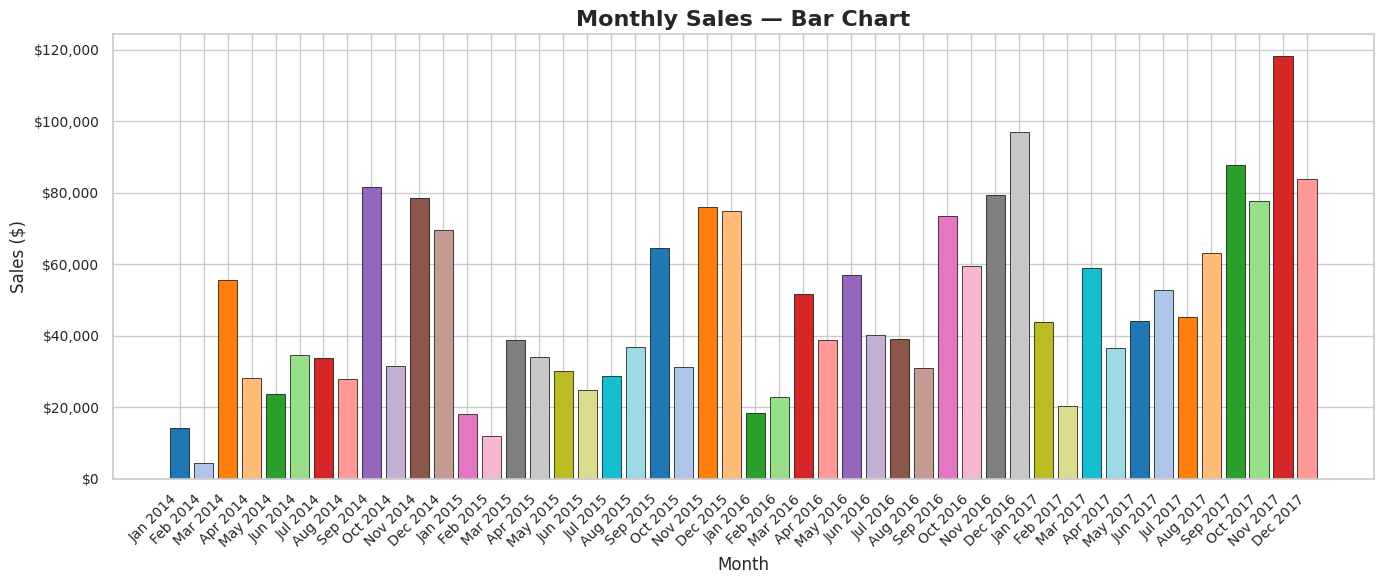

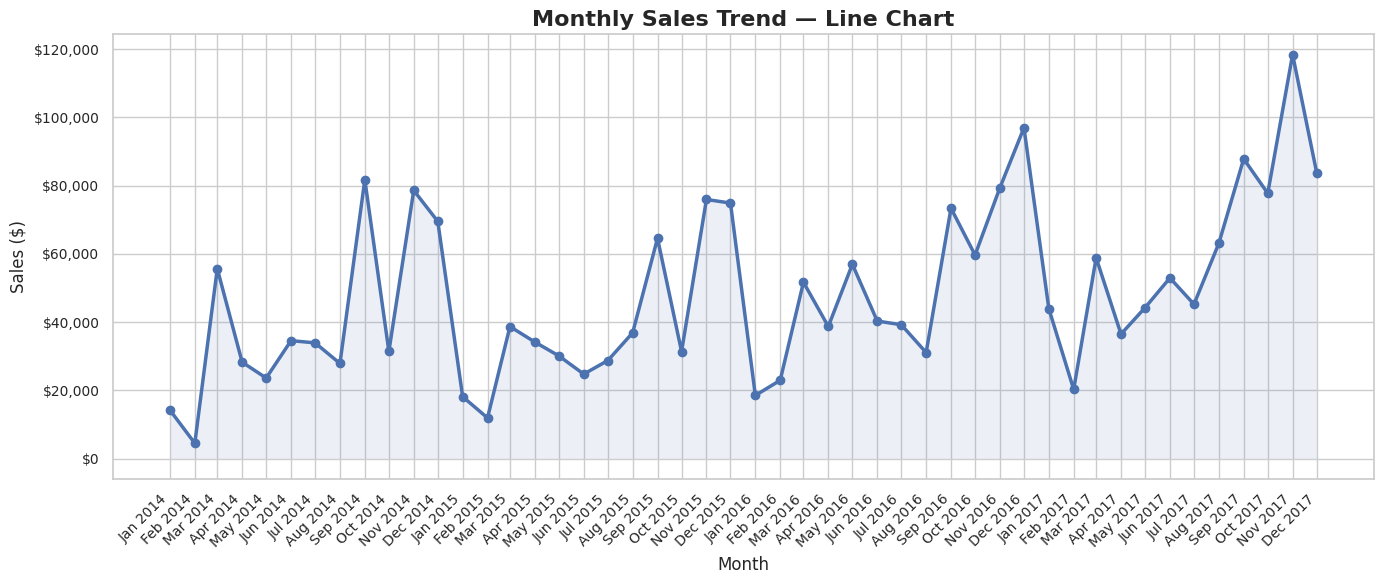

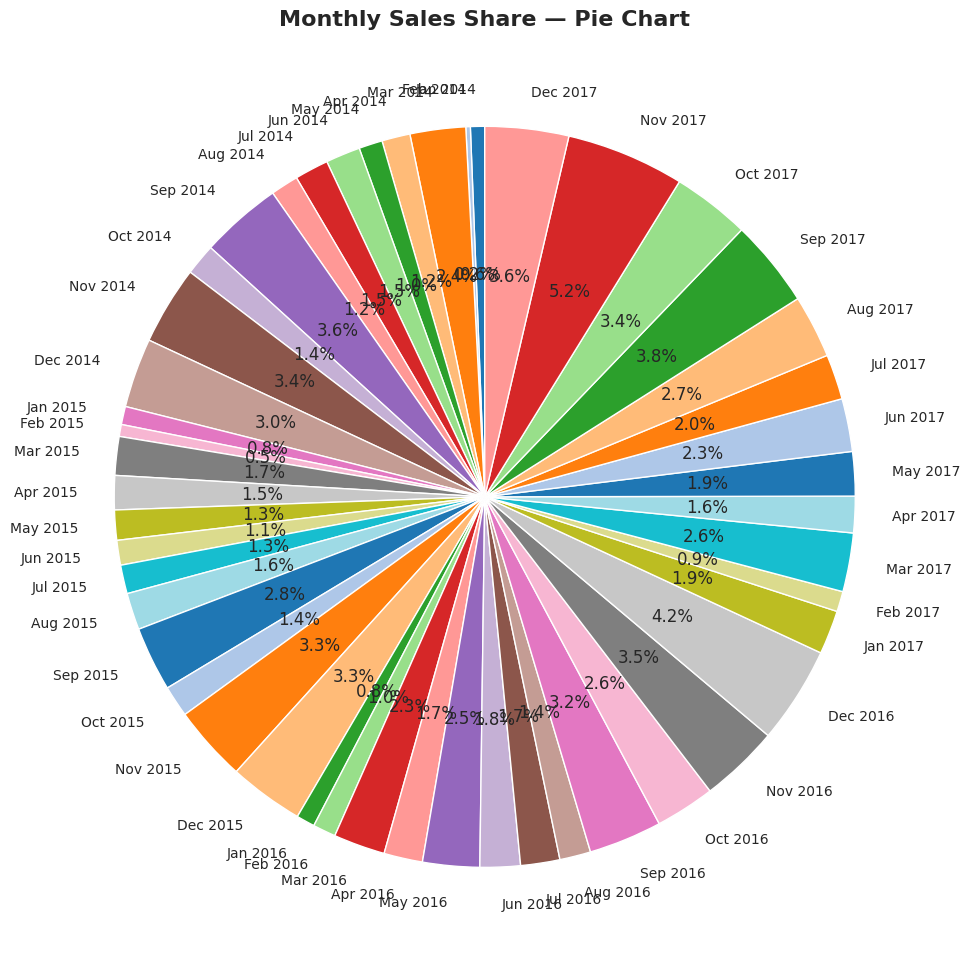

In [7]:
# ============================================
# TASK 1 — SAME DATA, MULTIPLE CHART TYPES
# ============================================

monthly_sales = (
    df.groupby("Month")["Sales"]
      .sum()
      .reset_index()
)

monthly_sales["Month"] = monthly_sales["Month"].dt.to_timestamp()
monthly_sales["Month_Label"] = monthly_sales["Month"].dt.strftime("%b %Y")

# --------------------------------------------
# 1A — BAR CHART
# --------------------------------------------

plt.figure(figsize=(14, 6))

bars = plt.bar(
    monthly_sales["Month_Label"],
    monthly_sales["Sales"],
    color=sns.color_palette("tab20", len(monthly_sales)),
    edgecolor="black",
    linewidth=0.5
)

plt.title("Monthly Sales — Bar Chart", fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.xticks(rotation=45, ha="right")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

plt.tight_layout()
plt.show()


# --------------------------------------------
# 1B — LINE CHART
# --------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Sales"],
    marker="o",
    linewidth=2.5,
    markersize=6
)

plt.fill_between(
    monthly_sales["Month"],
    monthly_sales["Sales"],
    alpha=0.10
)

plt.title("Monthly Sales Trend — Line Chart", fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Sales ($)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

plt.xticks(
    monthly_sales["Month"],
    monthly_sales["Month_Label"],
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()


# --------------------------------------------
# 1C — PIE CHART
# --------------------------------------------

plt.figure(figsize=(10, 10))

plt.pie(
    monthly_sales["Sales"],
    labels=monthly_sales["Month_Label"],
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("tab20", len(monthly_sales)),
    wedgeprops={"edgecolor": "white", "linewidth": 1}
)

plt.title(
    "Monthly Sales Share — Pie Chart",
    fontweight="bold"
)

plt.tight_layout()
plt.show()

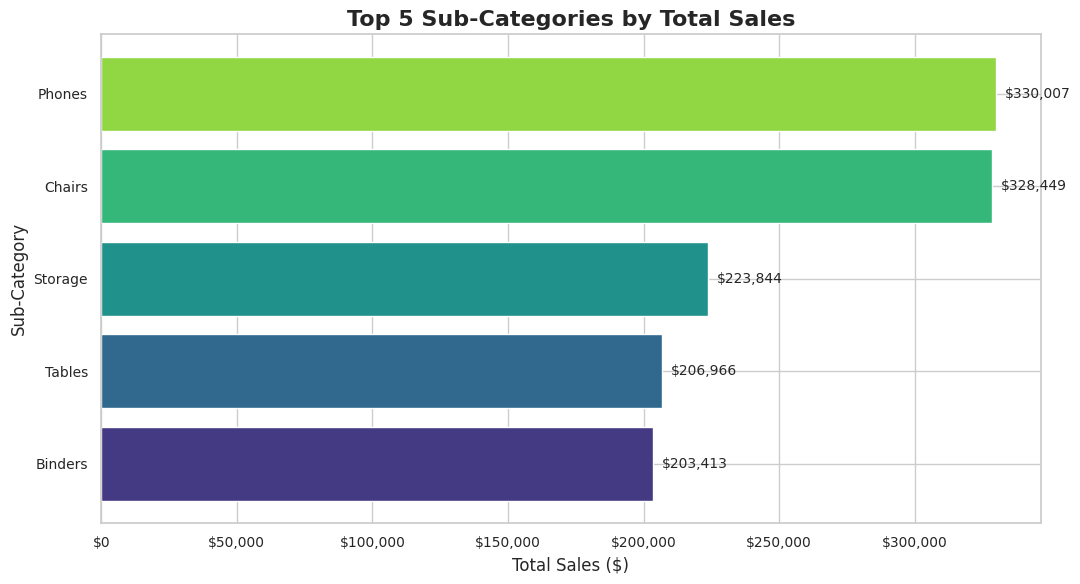

In [8]:
# ============================================
# TASK 2A — TOP 5 SUB-CATEGORIES
# ============================================

top5_subcategories = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(5)
      .sort_values()
)

plt.figure(figsize=(11, 6))

bars = plt.barh(
    top5_subcategories.index,
    top5_subcategories.values,
    color=sns.color_palette("viridis", 5)
)

plt.title(
    "Top 5 Sub-Categories by Total Sales",
    fontweight="bold"
)

plt.xlabel("Total Sales ($)")
plt.ylabel("Sub-Category")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

# Add values
for bar, value in zip(bars, top5_subcategories.values):
    plt.text(
        bar.get_width() + top5_subcategories.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"${value:,.0f}",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

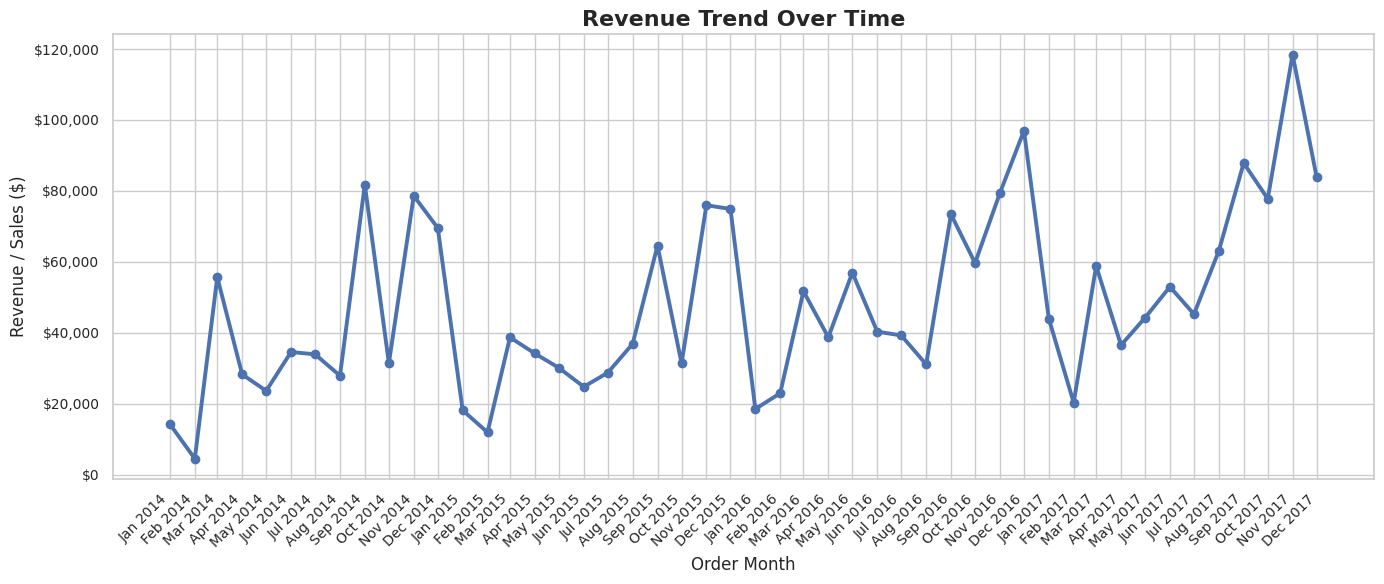

In [9]:
# ============================================
# TASK 2B — REVENUE TREND OVER TIME
# ============================================

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Sales"],
    marker="o",
    linewidth=2.8,
    markersize=6
)

plt.title(
    "Revenue Trend Over Time",
    fontweight="bold"
)

plt.xlabel("Order Month")
plt.ylabel("Revenue / Sales ($)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

plt.xticks(
    monthly_sales["Month"],
    monthly_sales["Month_Label"],
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

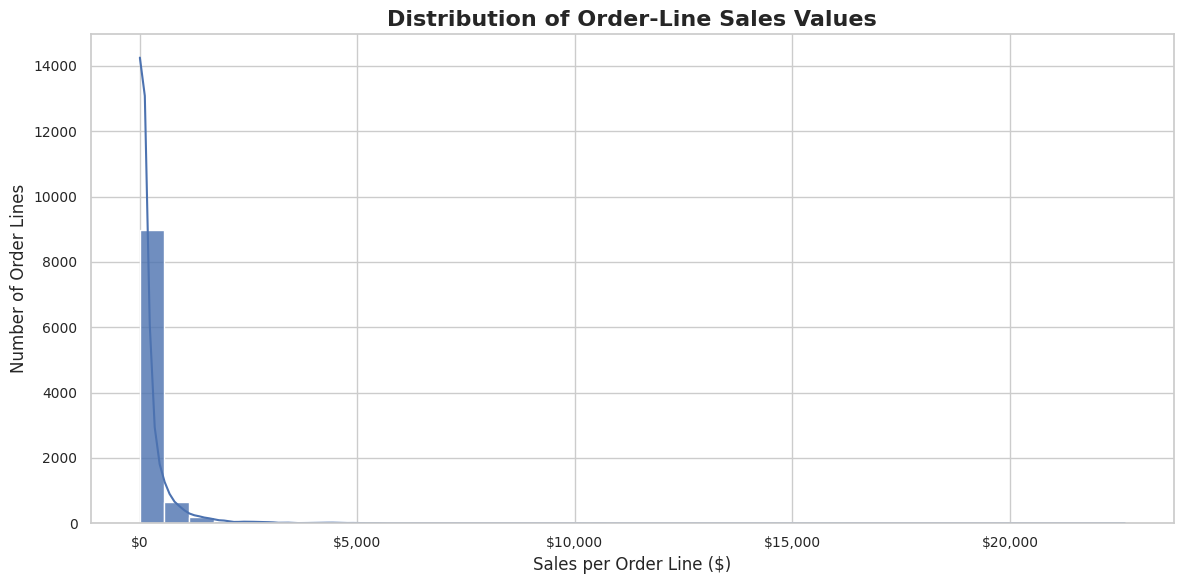

In [10]:
# ============================================
# TASK 2C — DISTRIBUTION OF SALES VALUES
# ============================================

plt.figure(figsize=(12, 6))

sns.histplot(
    df["Sales"],
    bins=40,
    kde=True,
    edgecolor="white",
    alpha=0.8
)

plt.title(
    "Distribution of Order-Line Sales Values",
    fontweight="bold"
)

plt.xlabel("Sales per Order Line ($)")
plt.ylabel("Number of Order Lines")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

plt.tight_layout()
plt.show()

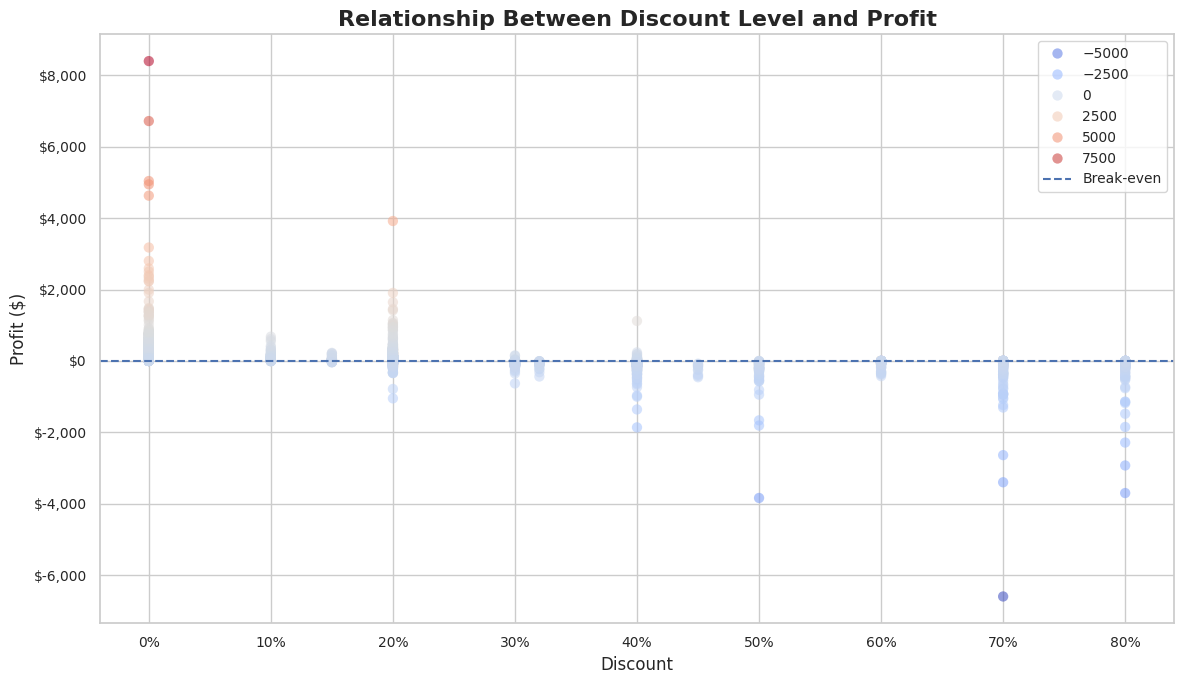

In [11]:
# ============================================
# TASK 2D — DISCOUNT VS PROFIT
# ============================================

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    hue="Profit",
    palette="coolwarm",
    alpha=0.55,
    s=55,
    edgecolor="none"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1.5,
    label="Break-even"
)

plt.title(
    "Relationship Between Discount Level and Profit",
    fontweight="bold"
)

plt.xlabel("Discount")
plt.ylabel("Profit ($)")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:.0%}")
)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

plt.legend()

plt.tight_layout()
plt.show()

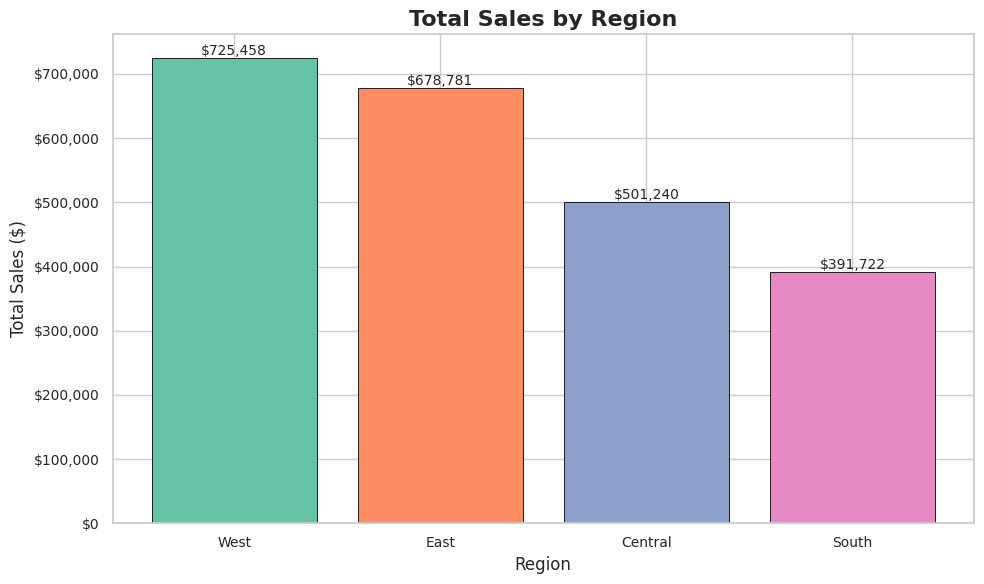

In [12]:
# ============================================
# TASK 3A — CATEGORICAL COLOR PALETTE
# ============================================

region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    region_sales.index,
    region_sales.values,
    color=sns.color_palette("Set2", len(region_sales)),
    edgecolor="black",
    linewidth=0.6
)

plt.title(
    "Total Sales by Region",
    fontweight="bold"
)

plt.xlabel("Region")
plt.ylabel("Total Sales ($)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

for bar, value in zip(bars, region_sales.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"${value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

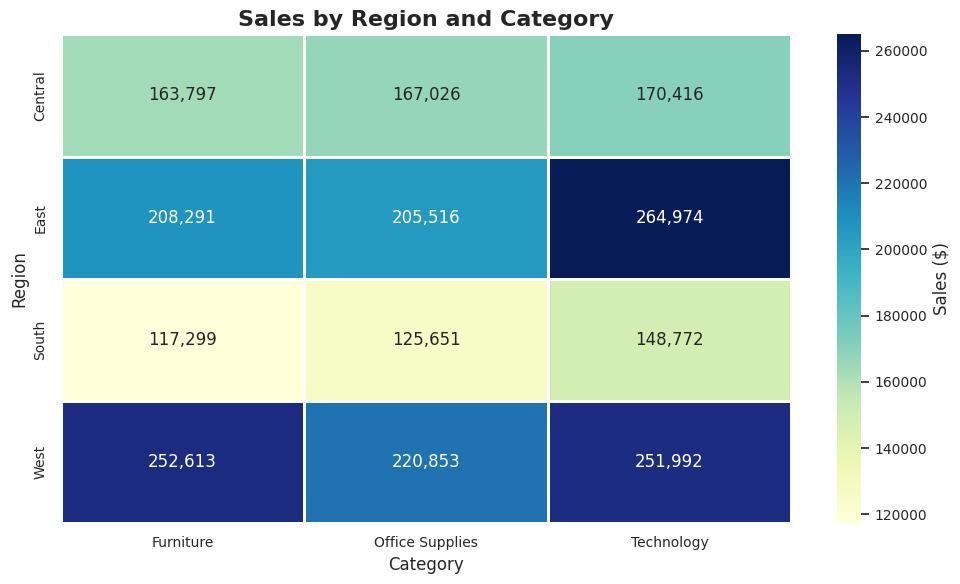

In [13]:
# ============================================
# TASK 3B — SEQUENTIAL HEATMAP
# ============================================

region_category_sales = pd.pivot_table(
    df,
    values="Sales",
    index="Region",
    columns="Category",
    aggfunc="sum"
)

plt.figure(figsize=(10, 6))

sns.heatmap(
    region_category_sales,
    annot=True,
    fmt=",.0f",
    cmap="YlGnBu",
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Sales ($)"}
)

plt.title(
    "Sales by Region and Category",
    fontweight="bold"
)

plt.xlabel("Category")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

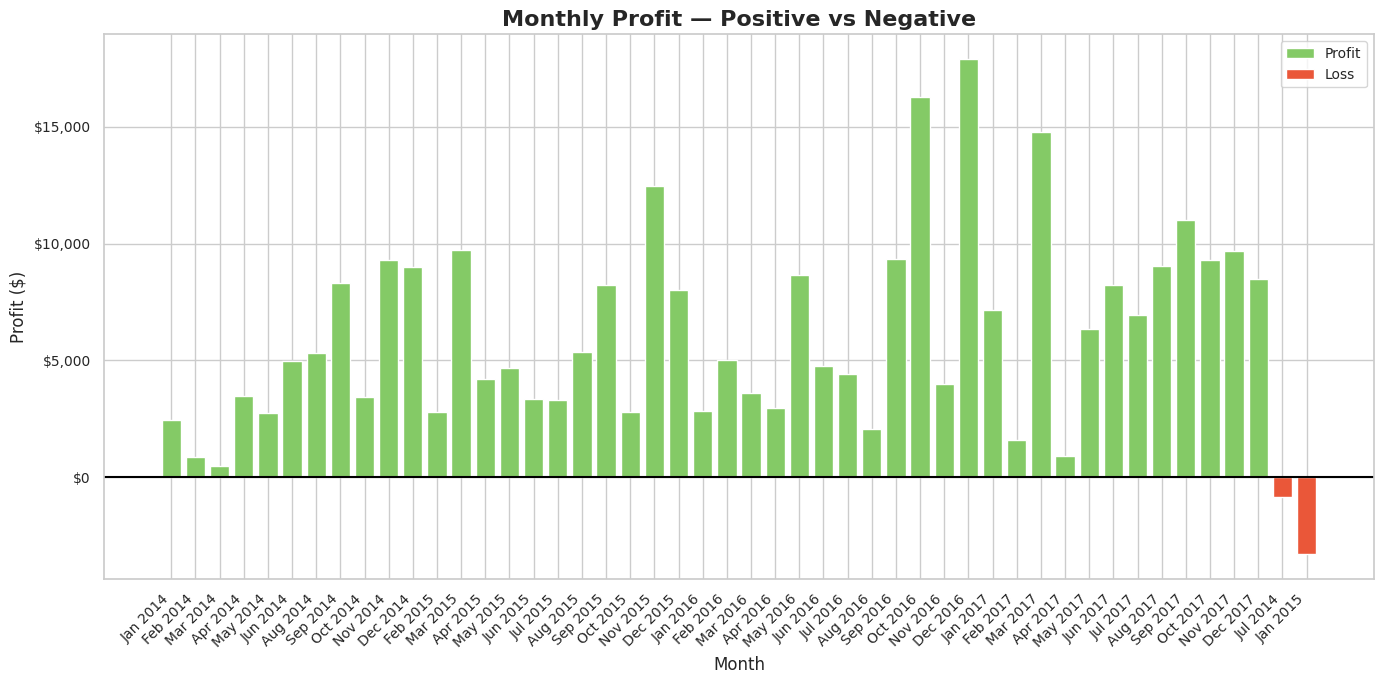

In [14]:
# ============================================
# TASK 3C — DIVERGING PROFIT VISUALIZATION
# ============================================

monthly_profit = (
    df.groupby("Month")["Profit"]
      .sum()
      .reset_index()
)

monthly_profit["Month"] = monthly_profit["Month"].dt.to_timestamp()
monthly_profit["Month_Label"] = monthly_profit["Month"].dt.strftime("%b %Y")

plt.figure(figsize=(14, 7))

# Positive and negative values receive different visual emphasis
positive = monthly_profit["Profit"] >= 0
negative = monthly_profit["Profit"] < 0

plt.bar(
    monthly_profit.loc[positive, "Month_Label"],
    monthly_profit.loc[positive, "Profit"],
    color=sns.color_palette("RdYlGn", 11)[-3],
    label="Profit"
)

plt.bar(
    monthly_profit.loc[negative, "Month_Label"],
    monthly_profit.loc[negative, "Profit"],
    color=sns.color_palette("RdYlGn", 11)[1],
    label="Loss"
)

plt.axhline(
    0,
    color="black",
    linewidth=1.5
)

plt.title(
    "Monthly Profit — Positive vs Negative",
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Profit ($)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

plt.xticks(rotation=45, ha="right")

plt.legend()

plt.tight_layout()
plt.show()

In [15]:
# ============================================
# TASK 4A — WCAG CONTRAST RATIO
# ============================================

def relative_luminance(rgb):
    """
    Calculate WCAG relative luminance.

    RGB values should be supplied as integers from 0 to 255.
    """

    rgb = np.array(rgb) / 255.0

    rgb_linear = np.where(
        rgb <= 0.03928,
        rgb / 12.92,
        ((rgb + 0.055) / 1.055) ** 2.4
    )

    r, g, b = rgb_linear

    return (
        0.2126 * r +
        0.7152 * g +
        0.0722 * b
    )


def contrast_ratio(rgb1, rgb2):
    """
    Calculate WCAG contrast ratio between two RGB colors.
    """

    L1 = relative_luminance(rgb1)
    L2 = relative_luminance(rgb2)

    lighter = max(L1, L2)
    darker = min(L1, L2)

    return (lighter + 0.05) / (darker + 0.05)


def check_contrast(name, foreground, background=(255, 255, 255)):
    ratio = contrast_ratio(foreground, background)

    status = "PASS" if ratio >= 4.5 else "FAIL"

    return {
        "Color": name,
        "RGB": foreground,
        "Background": background,
        "Contrast Ratio": round(ratio, 2),
        "WCAG AA Text": status
    }


# Example palette checks
contrast_results = pd.DataFrame([
    check_contrast(
        "Dark Blue",
        (31, 78, 121)
    ),
    check_contrast(
        "Dark Green",
        (34, 120, 60)
    ),
    check_contrast(
        "Dark Red",
        (160, 40, 40)
    ),
    check_contrast(
        "Light Yellow",
        (240, 220, 80)
    )
])

display(contrast_results)

,Color,RGB,Background,Contrast Ratio,WCAG AA Text
0,Dark Blue,"(31, 78, 121)","(255, 255, 255)",8.66,PASS
1,Dark Green,"(34, 120, 60)","(255, 255, 255)",5.50,PASS
2,Dark Red,"(160, 40, 40)","(255, 255, 255)",7.42,PASS
3,Light Yellow,"(240, 220, 80)","(255, 255, 255)",1.39,FAIL


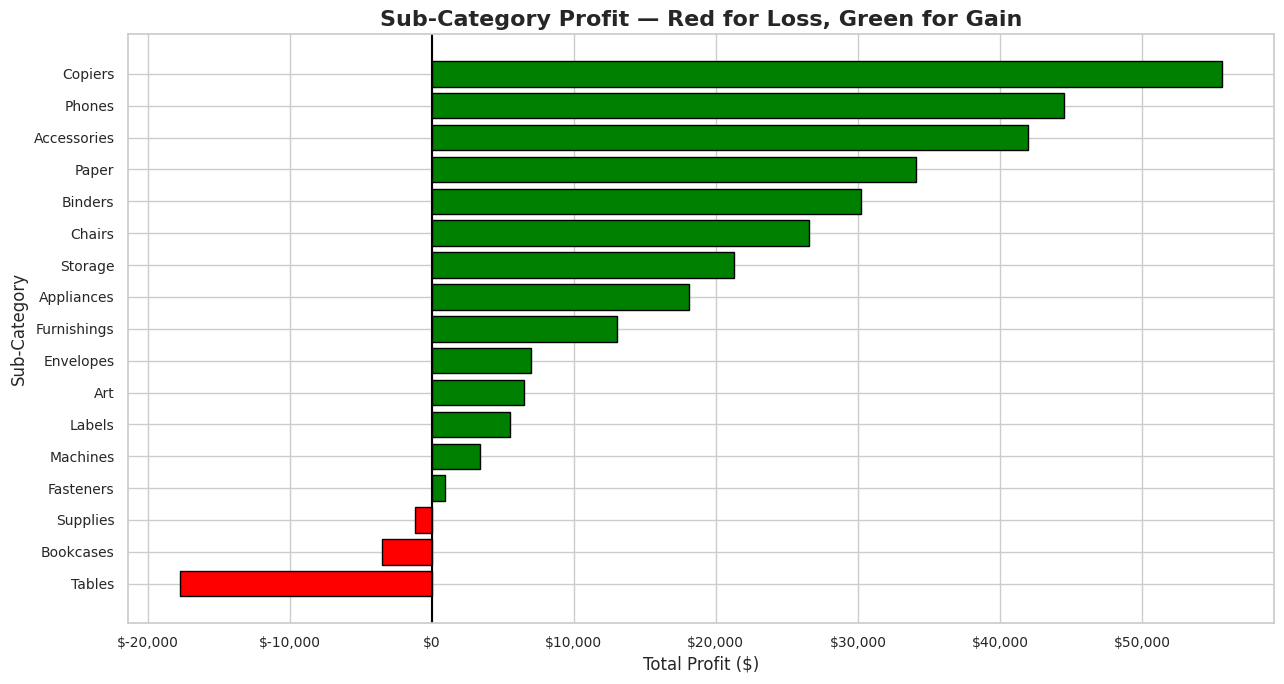

In [16]:
# ============================================
# TASK 4B — RED/GREEN GAIN VS LOSS
# ============================================

subcategory_profit = (
    df.groupby("Sub-Category")["Profit"]
      .sum()
      .sort_values()
)

plt.figure(figsize=(13, 7))

colors = [
    "red" if value < 0 else "green"
    for value in subcategory_profit.values
]

bars = plt.barh(
    subcategory_profit.index,
    subcategory_profit.values,
    color=colors,
    edgecolor="black"
)

plt.axvline(
    0,
    color="black",
    linewidth=1.5
)

plt.title(
    "Sub-Category Profit — Red for Loss, Green for Gain",
    fontweight="bold"
)

plt.xlabel("Total Profit ($)")
plt.ylabel("Sub-Category")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

plt.tight_layout()
plt.show()

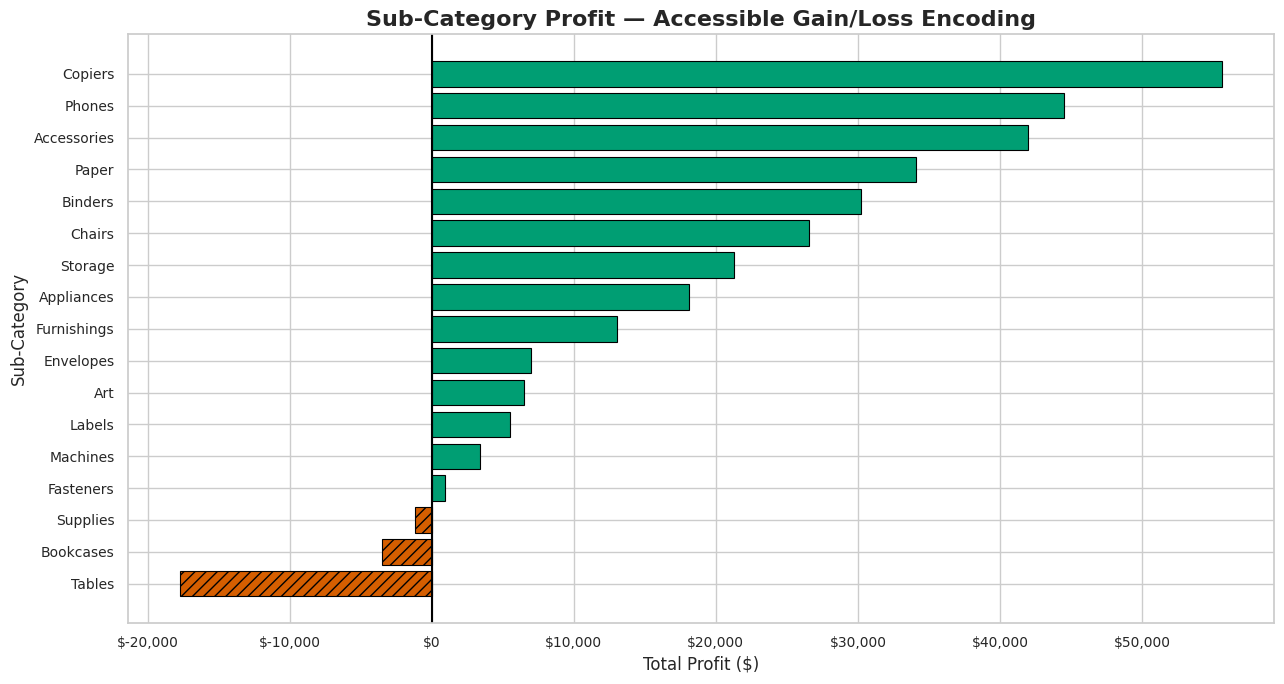

In [17]:
# ============================================
# TASK 4C — ACCESSIBLE FIX USING HATCHING
# ============================================

plt.figure(figsize=(13, 7))

bars = plt.barh(
    subcategory_profit.index,
    subcategory_profit.values,
    color=[
        "#D55E00" if value < 0 else "#009E73"
        for value in subcategory_profit.values
    ],
    edgecolor="black",
    linewidth=0.8
)

# Add hatching to encode loss separately from color
for bar, value in zip(bars, subcategory_profit.values):
    if value < 0:
        bar.set_hatch("///")
    else:
        bar.set_hatch("")

plt.axvline(
    0,
    color="black",
    linewidth=1.5
)

plt.title(
    "Sub-Category Profit — Accessible Gain/Loss Encoding",
    fontweight="bold"
)

plt.xlabel("Total Profit ($)")
plt.ylabel("Sub-Category")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

plt.tight_layout()
plt.show()

In [18]:
# ============================================
# TASK 4D — ALT TEXT
# ============================================

alt_text = (
    "Horizontal bar chart showing total profit by sub-category. "
    "Positive-profit sub-categories are shown with solid bars, while "
    "loss-making sub-categories use hatched bars. The zero line separates "
    "profit from loss, allowing the gain/loss distinction to remain visible "
    "without relying on color alone."
)

print("ALT TEXT:")
print(alt_text)

ALT TEXT:
Horizontal bar chart showing total profit by sub-category. Positive-profit sub-categories are shown with solid bars, while loss-making sub-categories use hatched bars. The zero line separates profit from loss, allowing the gain/loss distinction to remain visible without relying on color alone.


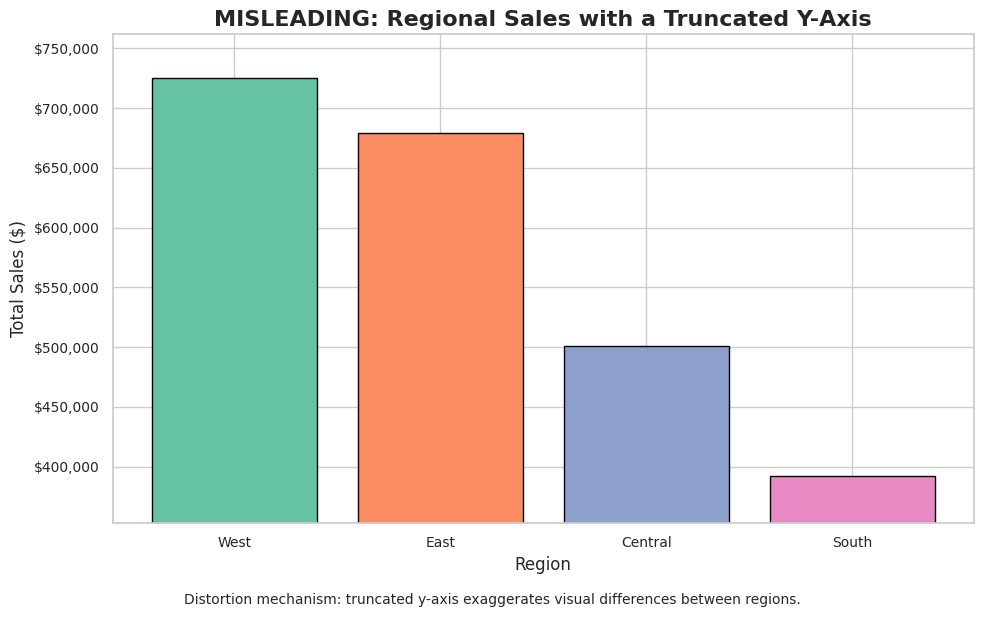

In [19]:
# ============================================
# TASK 5A — TRUNCATED Y-AXIS
# ============================================

plt.figure(figsize=(10, 6))

plt.bar(
    region_sales.index,
    region_sales.values,
    color=sns.color_palette("Set2", len(region_sales)),
    edgecolor="black"
)

# INTENTIONALLY MISLEADING
plt.ylim(
    region_sales.min() * 0.90,
    region_sales.max() * 1.05
)

plt.title(
    "MISLEADING: Regional Sales with a Truncated Y-Axis",
    fontweight="bold"
)

plt.xlabel("Region")
plt.ylabel("Total Sales ($)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

plt.figtext(
    0.5,
    -0.02,
    "Distortion mechanism: truncated y-axis exaggerates visual differences between regions.",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

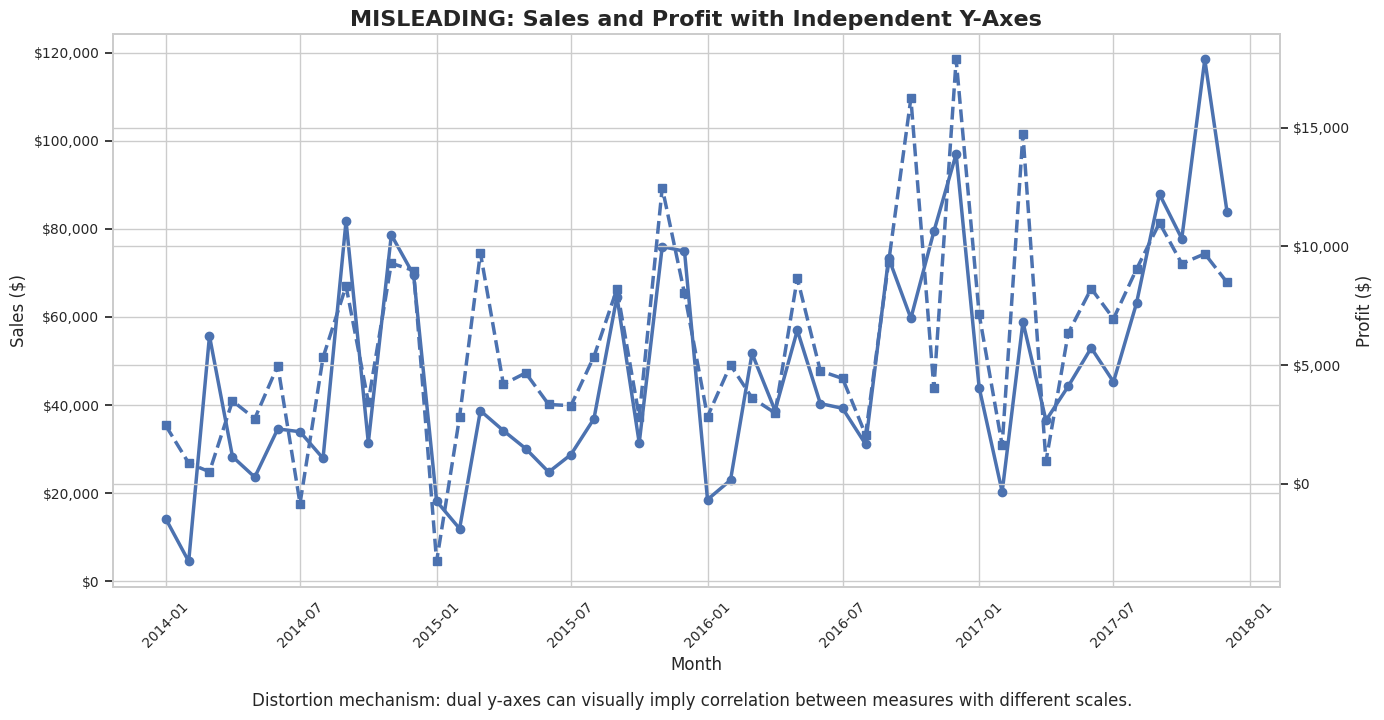

In [20]:
# ============================================
# TASK 5B — DUAL-AXIS MISLEADING CHART
# ============================================

monthly_sales_profit = (
    df.groupby("Month")
      .agg(
          Sales=("Sales", "sum"),
          Profit=("Profit", "sum")
      )
      .reset_index()
)

monthly_sales_profit["Month"] = (
    monthly_sales_profit["Month"].dt.to_timestamp()
)

fig, ax1 = plt.subplots(figsize=(14, 7))

# Sales
ax1.plot(
    monthly_sales_profit["Month"],
    monthly_sales_profit["Sales"],
    linewidth=2.5,
    marker="o",
    label="Sales"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Sales ($)")

ax1.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

# Profit on completely separate scale
ax2 = ax1.twinx()

ax2.plot(
    monthly_sales_profit["Month"],
    monthly_sales_profit["Profit"],
    linewidth=2.5,
    marker="s",
    linestyle="--",
    label="Profit"
)

ax2.set_ylabel("Profit ($)")

ax2.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

plt.title(
    "MISLEADING: Sales and Profit with Independent Y-Axes",
    fontweight="bold"
)

ax1.tick_params(axis="x", rotation=45)

fig.text(
    0.5,
    -0.02,
    "Distortion mechanism: dual y-axes can visually imply correlation between measures with different scales.",
    ha="center"
)

plt.tight_layout()
plt.show()

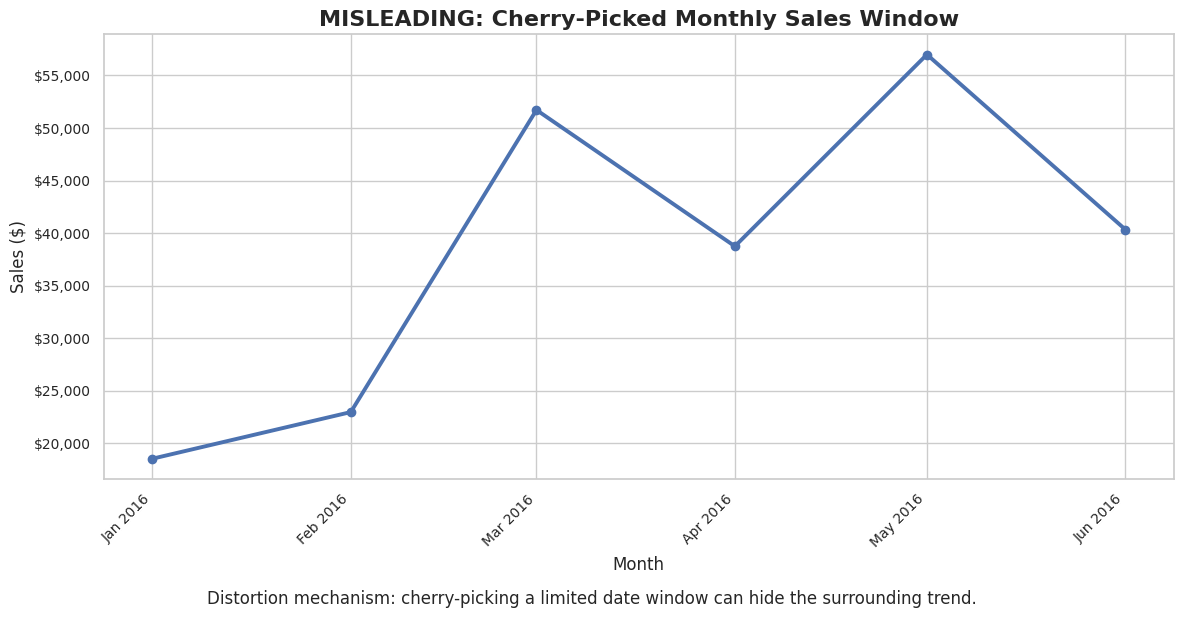

In [21]:
# ============================================
# TASK 5C — CHERRY-PICKED TIME WINDOW
# ============================================

# Choose a subset of months intentionally
# to demonstrate how selecting only a favorable period
# can change the apparent narrative.

cherry_picked = monthly_sales[
    (monthly_sales["Month"] >= "2016-01-01") &
    (monthly_sales["Month"] <= "2016-06-30")
]

plt.figure(figsize=(12, 6))

plt.plot(
    cherry_picked["Month"],
    cherry_picked["Sales"],
    marker="o",
    linewidth=2.8
)

plt.title(
    "MISLEADING: Cherry-Picked Monthly Sales Window",
    fontweight="bold"
)

plt.xlabel("Month")
plt.ylabel("Sales ($)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

plt.xticks(
    cherry_picked["Month"],
    cherry_picked["Month_Label"],
    rotation=45,
    ha="right"
)

plt.figtext(
    0.5,
    -0.02,
    "Distortion mechanism: cherry-picking a limited date window can hide the surrounding trend.",
    ha="center"
)

plt.tight_layout()
plt.show()

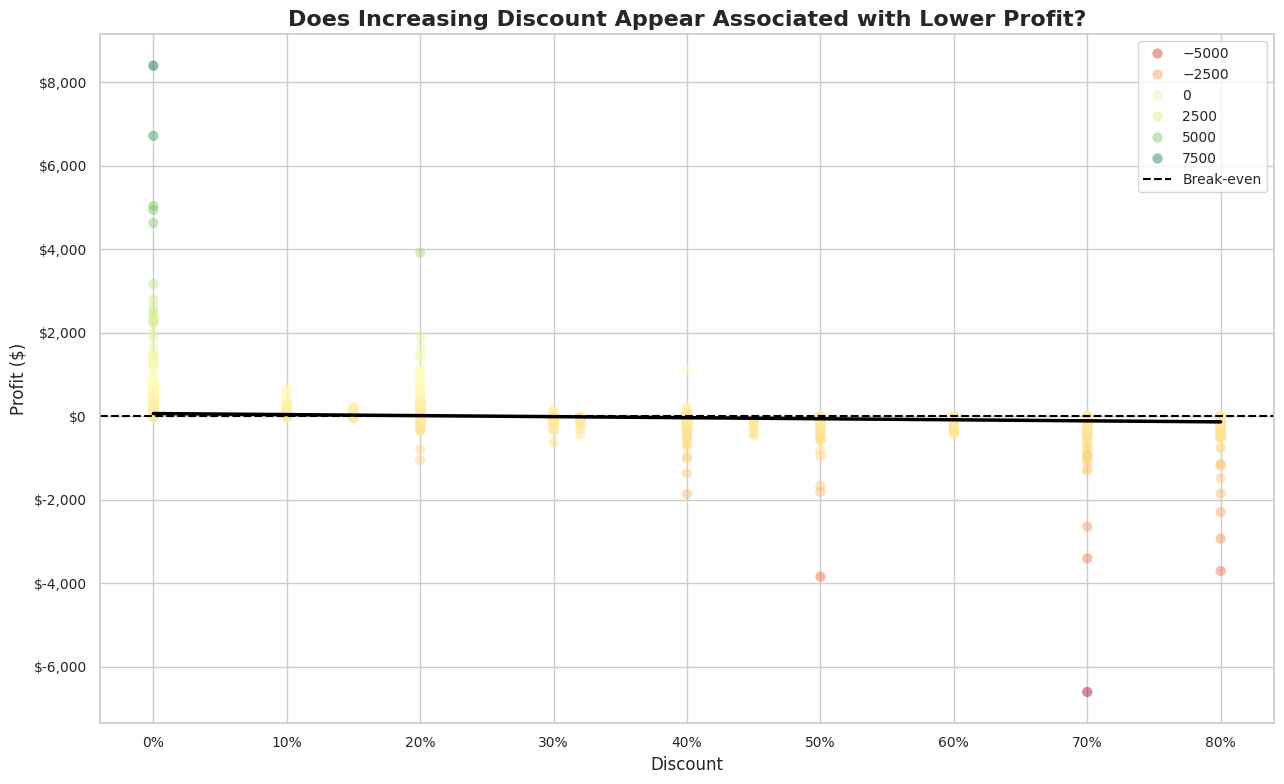

In [22]:
# ============================================
# TASK 6 — HONEST ANALYTICAL VISUALIZATION
# ============================================

plt.figure(figsize=(13, 8))

scatter = sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    hue="Profit",
    palette="RdYlGn",
    alpha=0.45,
    s=55,
    edgecolor="none"
)

# Break-even reference
plt.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Break-even"
)

# Add a trend line without changing the raw data
sns.regplot(
    data=df,
    x="Discount",
    y="Profit",
    scatter=False,
    color="black",
    line_kws={
        "linewidth": 2.5,
        "linestyle": "-"
    }
)

plt.title(
    "Does Increasing Discount Appear Associated with Lower Profit?",
    fontweight="bold"
)

plt.xlabel("Discount")
plt.ylabel("Profit ($)")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:.0%}")
)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

plt.legend()

plt.tight_layout()
plt.show()

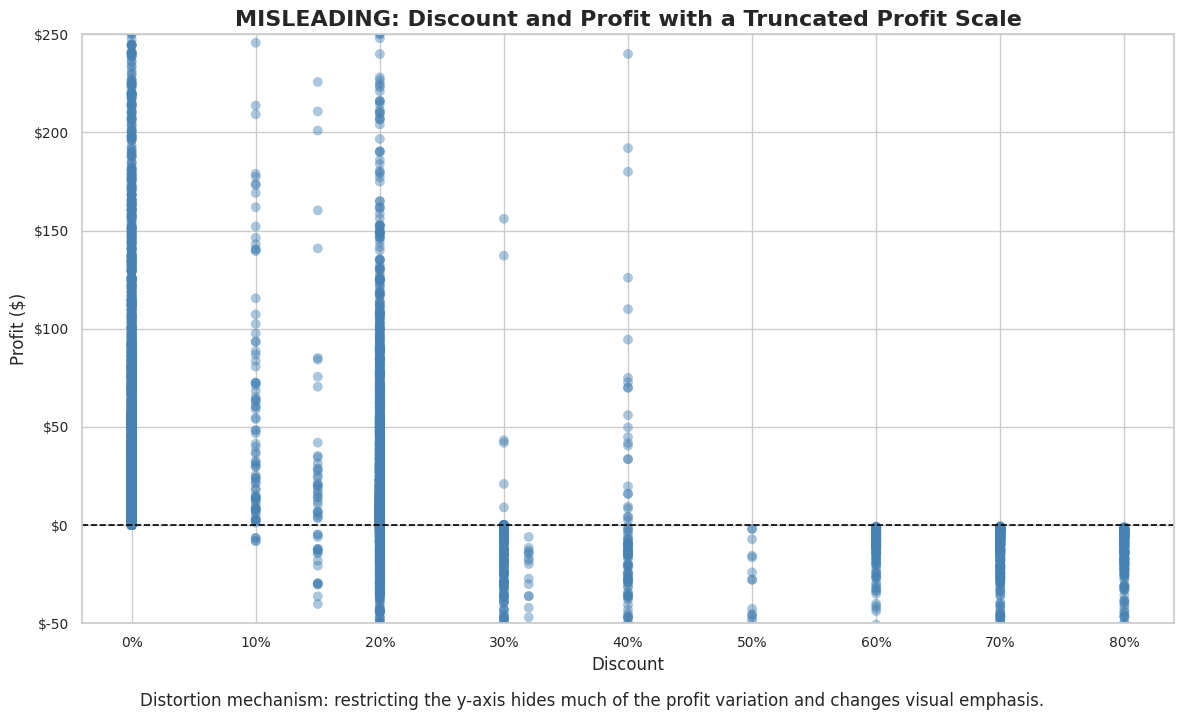

In [23]:
# ============================================
# TASK 6 — DELIBERATELY MISLEADING VERSION
# ============================================

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    color="steelblue",
    alpha=0.45,
    s=50,
    edgecolor="none"
)

# INTENTIONALLY TRUNCATE PROFIT AXIS
plt.ylim(
    -50,
    250
)

plt.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.2
)

plt.title(
    "MISLEADING: Discount and Profit with a Truncated Profit Scale",
    fontweight="bold"
)

plt.xlabel("Discount")
plt.ylabel("Profit ($)")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:.0%}")
)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:,.0f}")
)

plt.figtext(
    0.5,
    -0.02,
    "Distortion mechanism: restricting the y-axis hides much of the profit variation and changes visual emphasis.",
    ha="center"
)

plt.tight_layout()
plt.show()

In [24]:
# ============================================
# TASK 6 — JUSTIFICATION
# ============================================

justification = """
ANALYTICAL QUESTION
Does increasing discount appear to be associated with lower profit?

CHART TYPE
A scatter plot is appropriate because Discount and Profit are two numerical
variables and each point represents an individual order-line observation.
The plot allows the viewer to inspect the relationship, spread, outliers,
and whether profit tends to move as discount changes.

COLOR CHOICE
Profit is represented with a diverging color scheme centered conceptually
around zero, distinguishing losses from gains. The zero-profit reference
line provides an additional non-color cue.

ACCESSIBILITY
The visualization does not rely exclusively on color because the zero line,
axis labels, and point positions independently communicate the information.
A colorblind-safe palette should be preferred over a red/green-only scheme.

HONEST VS MISLEADING VERSION
The honest visualization preserves the full range of the profit data.
The misleading version deliberately restricts the y-axis, changing the
visual emphasis and potentially exaggerating the apparent pattern.

INTERPRETATION
The visualization can show an association between discount and profit,
but association alone does not establish that discount causes changes
in profit. Other factors such as product, category, quantity, and market
conditions may also influence profit.
"""

print(justification)


ANALYTICAL QUESTION
Does increasing discount appear to be associated with lower profit?

CHART TYPE
A scatter plot is appropriate because Discount and Profit are two numerical
variables and each point represents an individual order-line observation.
The plot allows the viewer to inspect the relationship, spread, outliers,
and whether profit tends to move as discount changes.

COLOR CHOICE
Profit is represented with a diverging color scheme centered conceptually
around zero, distinguishing losses from gains. The zero-profit reference
line provides an additional non-color cue.

ACCESSIBILITY
The visualization does not rely exclusively on color because the zero line,
axis labels, and point positions independently communicate the information.
A colorblind-safe palette should be preferred over a red/green-only scheme.

HONEST VS MISLEADING VERSION
The honest visualization preserves the full range of the profit data.
The misleading version deliberately restricts the y-axis, changing the
vis

In [25]:
# ============================================
# FINAL VISUALIZATION QUALITY CHECK
# ============================================

quality_check = {
    "Appropriate chart types": "PASS",
    "Axes clearly labeled": "PASS",
    "Meaningful titles": "PASS",
    "Color palette matches data type": "PASS",
    "No unnecessary 3D effects": "PASS",
    "Zero reference used where meaningful": "PASS",
    "Accessibility considered": "PASS",
    "Color not used as the only encoding": "PASS",
    "Misleading mechanisms explicitly labeled": "PASS",
    "Raw data used where required": "PASS",
    "No unsupported causal claims": "PASS"
}

for item, status in quality_check.items():
    print(f"✓ {item}: {status}")

✓ Appropriate chart types: PASS
✓ Axes clearly labeled: PASS
✓ Meaningful titles: PASS
✓ Color palette matches data type: PASS
✓ No unnecessary 3D effects: PASS
✓ Zero reference used where meaningful: PASS
✓ Accessibility considered: PASS
✓ Color not used as the only encoding: PASS
✓ Misleading mechanisms explicitly labeled: PASS
✓ Raw data used where required: PASS
✓ No unsupported causal claims: PASS
